<a href="https://colab.research.google.com/github/Zakycuy/PCVK_Genap_2026/blob/PCVK_2026/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

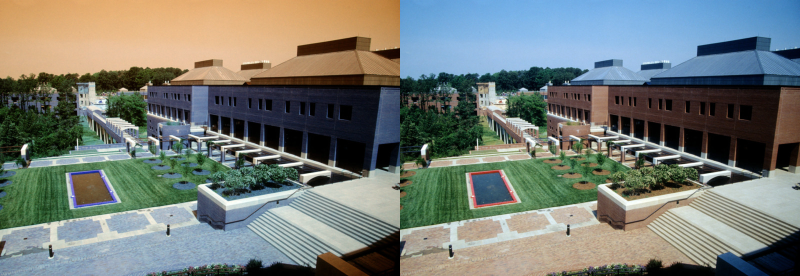

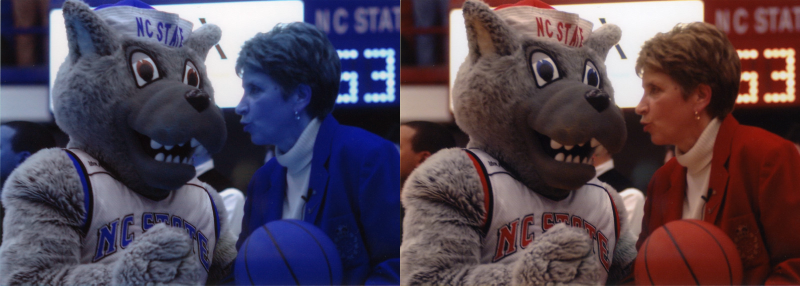

In [ ]:
# Membuat list untuk menyimpan url dari beberapa image
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        ]

# karena Web server down di foto ke 3
# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in urls:
    image = io.imread(url)                      #read image
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5) #resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB) #convert color to RGB
    final_frame = cv.hconcat((image, image_2))  #concatenate image
    cv2_imshow(final_frame)                     #show image
    print('\n')

resolusi image: tinggi x lebar =  286  x  400


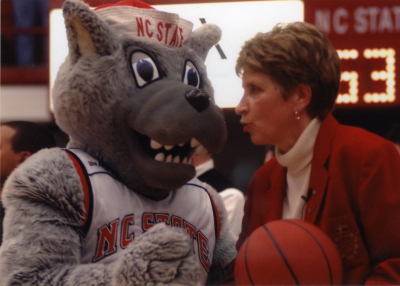

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ",tinggi," x ",lebar)
cv2_imshow(image_2)

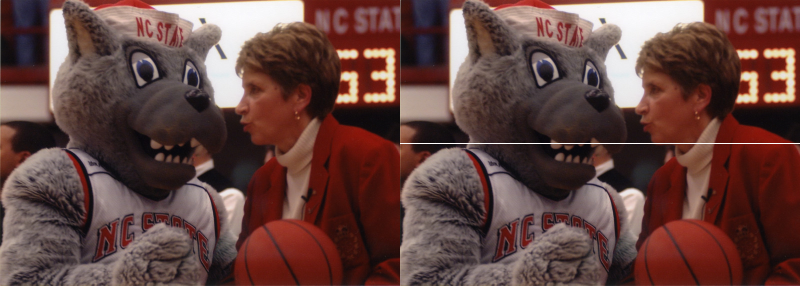

In [17]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# membuat garis horizontal ditengah image
for y in range(lebar):
    image_3[int((tinggi)/2), y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

1. Using Google Colab makes it easy to run code because the platform runs in the cloud. Users do not need to install Python, an Integrated Development Environment (IDE), or supporting libraries (such as OpenCV) on their local computers. In addition, Colab provides ample free computing resources and makes it easy to share and store scripts online.

2. Not all libraries are required in every session. For example, if an image is read from Colab’s local storage instead of from a URL, the skimage library is not needed.

*   skimage.io: Used specifically to read image files sourced from internet URLs.

*   google.colab.patches.cv2_imshow: Required in the Google Colab environment to display images, as the built-in cv2.imshow function can cause the system to crash.

*   (OpenCV): A core library required for manipulating images, such as changing color spaces and resizing.

3. This function resizes the image to 50% (half) of its original size, represented by the parameters fx=0.5 on the X-axis (width) and fy=0.5 on the Y-axis (height). If this code is not executed, the image will remain at its original size. Consequently, if the original image has a very high resolution, the computation process will consume more memory, take longer to execute, and the image will appear too large on the screen.

4. BGR (Blue, Green, Red) or RGB colors with 8-bit depth; a value of 255 represents the maximum light intensity for a single color channel. An array [255, 255, 255] means a mixture of the maximum intensities of blue, green, and red, which produces the color white. In the code, this value is used to color the pixel at a specific coordinate as a white line.

5. High-resolution images have a very large and dense number of pixels, allowing them to display fine details without becoming pixelated when zoomed in. Conversely, low-resolution images have few pixels; as a result, image details are reduced, appear blurry, and will look pixelated when displayed on a large screen. A pixel (Picture Element) is the smallest colored point that makes up a digital image. Resolution refers to the total number of pixels in the image’s dimensions (width x height).


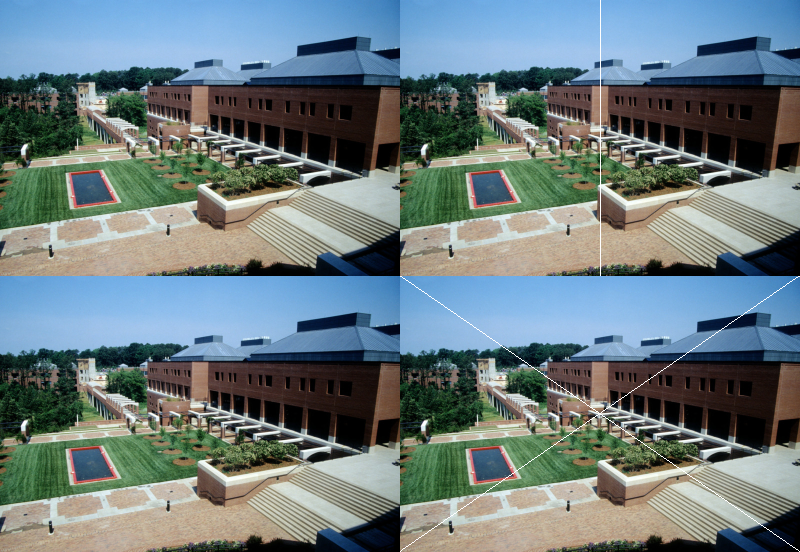

In [21]:
img_base = cv.cvtColor(image, cv.COLOR_RGB2BGR)
tinggi, lebar = img_base.shape[:2]

img1 = img_base.copy()
img3 = img_base.copy()

# Gambar 2 (Kanan Atas): Garis vertikal putih tepat di tengah
img2 = img_base.copy()
for x in range(tinggi):
    img2[x, int(lebar/2)] = [255, 255, 255]

# Gambar 4 (Kanan Bawah): Garis diagonal menyilang (huruf X) putih
img4 = img_base.copy()
for x in range(lebar):
    # Diagonal dari kiri-atas ke kanan-bawah (Y = X * tinggi/lebar)
    y1 = int(x * (tinggi / lebar))
    if 0 <= y1 < tinggi:
        img4[y1, x] = [255, 255, 255]

    # Diagonal dari kiri-bawah ke kanan-atas
    y2 = int(tinggi - 1 - (x * (tinggi / lebar)))
    if 0 <= y2 < tinggi:
        img4[y2, x] = [255, 255, 255]

baris_atas = cv.hconcat((img1, img2))
baris_bawah = cv.hconcat((img3, img4))

final_frame = cv.vconcat((baris_atas, baris_bawah))

# Tampilkan hasil grid 2x2
cv2_imshow(final_frame)

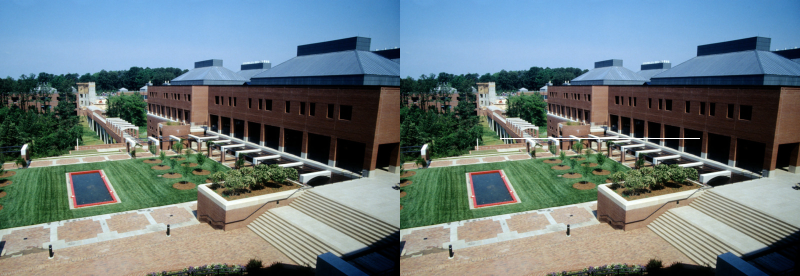

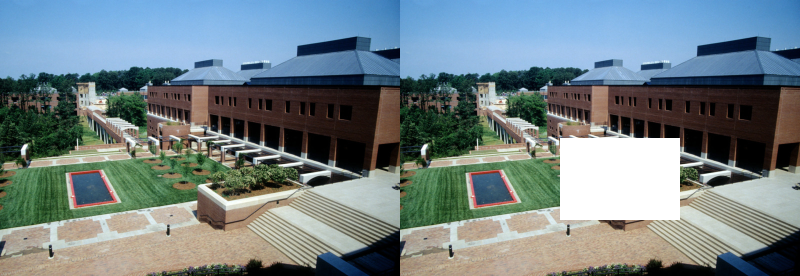

In [23]:
img_base = cv.cvtColor(image, cv.COLOR_RGB2BGR)
tinggi, lebar = img_base.shape[:2]

img_soal3_kiri = img_base.copy()
img_soal3_kanan = img_base.copy()

x_awal = int(lebar * 0.25)
x_akhir = int(lebar * 0.75)
y_tengah = int(tinggi / 2)

for x in range(x_awal, x_akhir):
    img_soal3_kanan[y_tengah, x] = [255, 255, 255]

hasil_soal3 = cv.hconcat((img_soal3_kiri, img_soal3_kanan))
cv2_imshow(hasil_soal3)
print("\n")

img_soal4_kiri = img_base.copy()
img_soal4_kanan = img_base.copy()

y_mulai = int(tinggi * 0.5)
y_selesai = int(tinggi * 0.8)
x_mulai = int(lebar * 0.4)
x_selesai = int(lebar * 0.7)

img_soal4_kanan[y_mulai:y_selesai, x_mulai:x_selesai] = [255, 255, 255]

hasil_soal4 = cv.hconcat((img_soal4_kiri, img_soal4_kanan))
cv2_imshow(hasil_soal4)